In [6]:
import sys
import os

sys.path.append(os.path.expanduser('~/.local/lib/python3.12/site-packages'))

from xgboost import XGBClassifier
print("Импорт прошел успешно!")

Импорт прошел успешно!


In [7]:
import sys
!{sys.executable} -m pip install --user shap

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import cross_val_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [9]:
b_churn=pd.read_csv('Bank Customer Churn Prediction.csv')
b_churn.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


---------------------------------------------------------------------------------------

Data understanding and cleaning

---------------------------------------------------------------------------------------

In [10]:
b_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


From this table we can clearly see that our data diesnt have any null values

In [11]:
b_churn.duplicated().sum()

np.int64(0)

we dont have any duplicates

In [12]:
b_churn["churn"].value_counts()

,count
churn,
0,7963
1,2037


From here we can clearly see that the data is imbalanced as the num of non-churn clients
is much bigger than the churn ones

In [13]:

b_churn["country"].value_counts()

,count
country,
France,5014
Germany,2509
Spain,2477


In [14]:
b_churn["gender"].value_counts()

,count
gender,
Male,5457
Female,4543


In [15]:
b_churn.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [16]:
min_thresold,max_thresold=b_churn.age.quantile([0.001,0.999])
min_thresold,max_thresold


(18.0, 81.0)

We don't have any abnormal values which is great

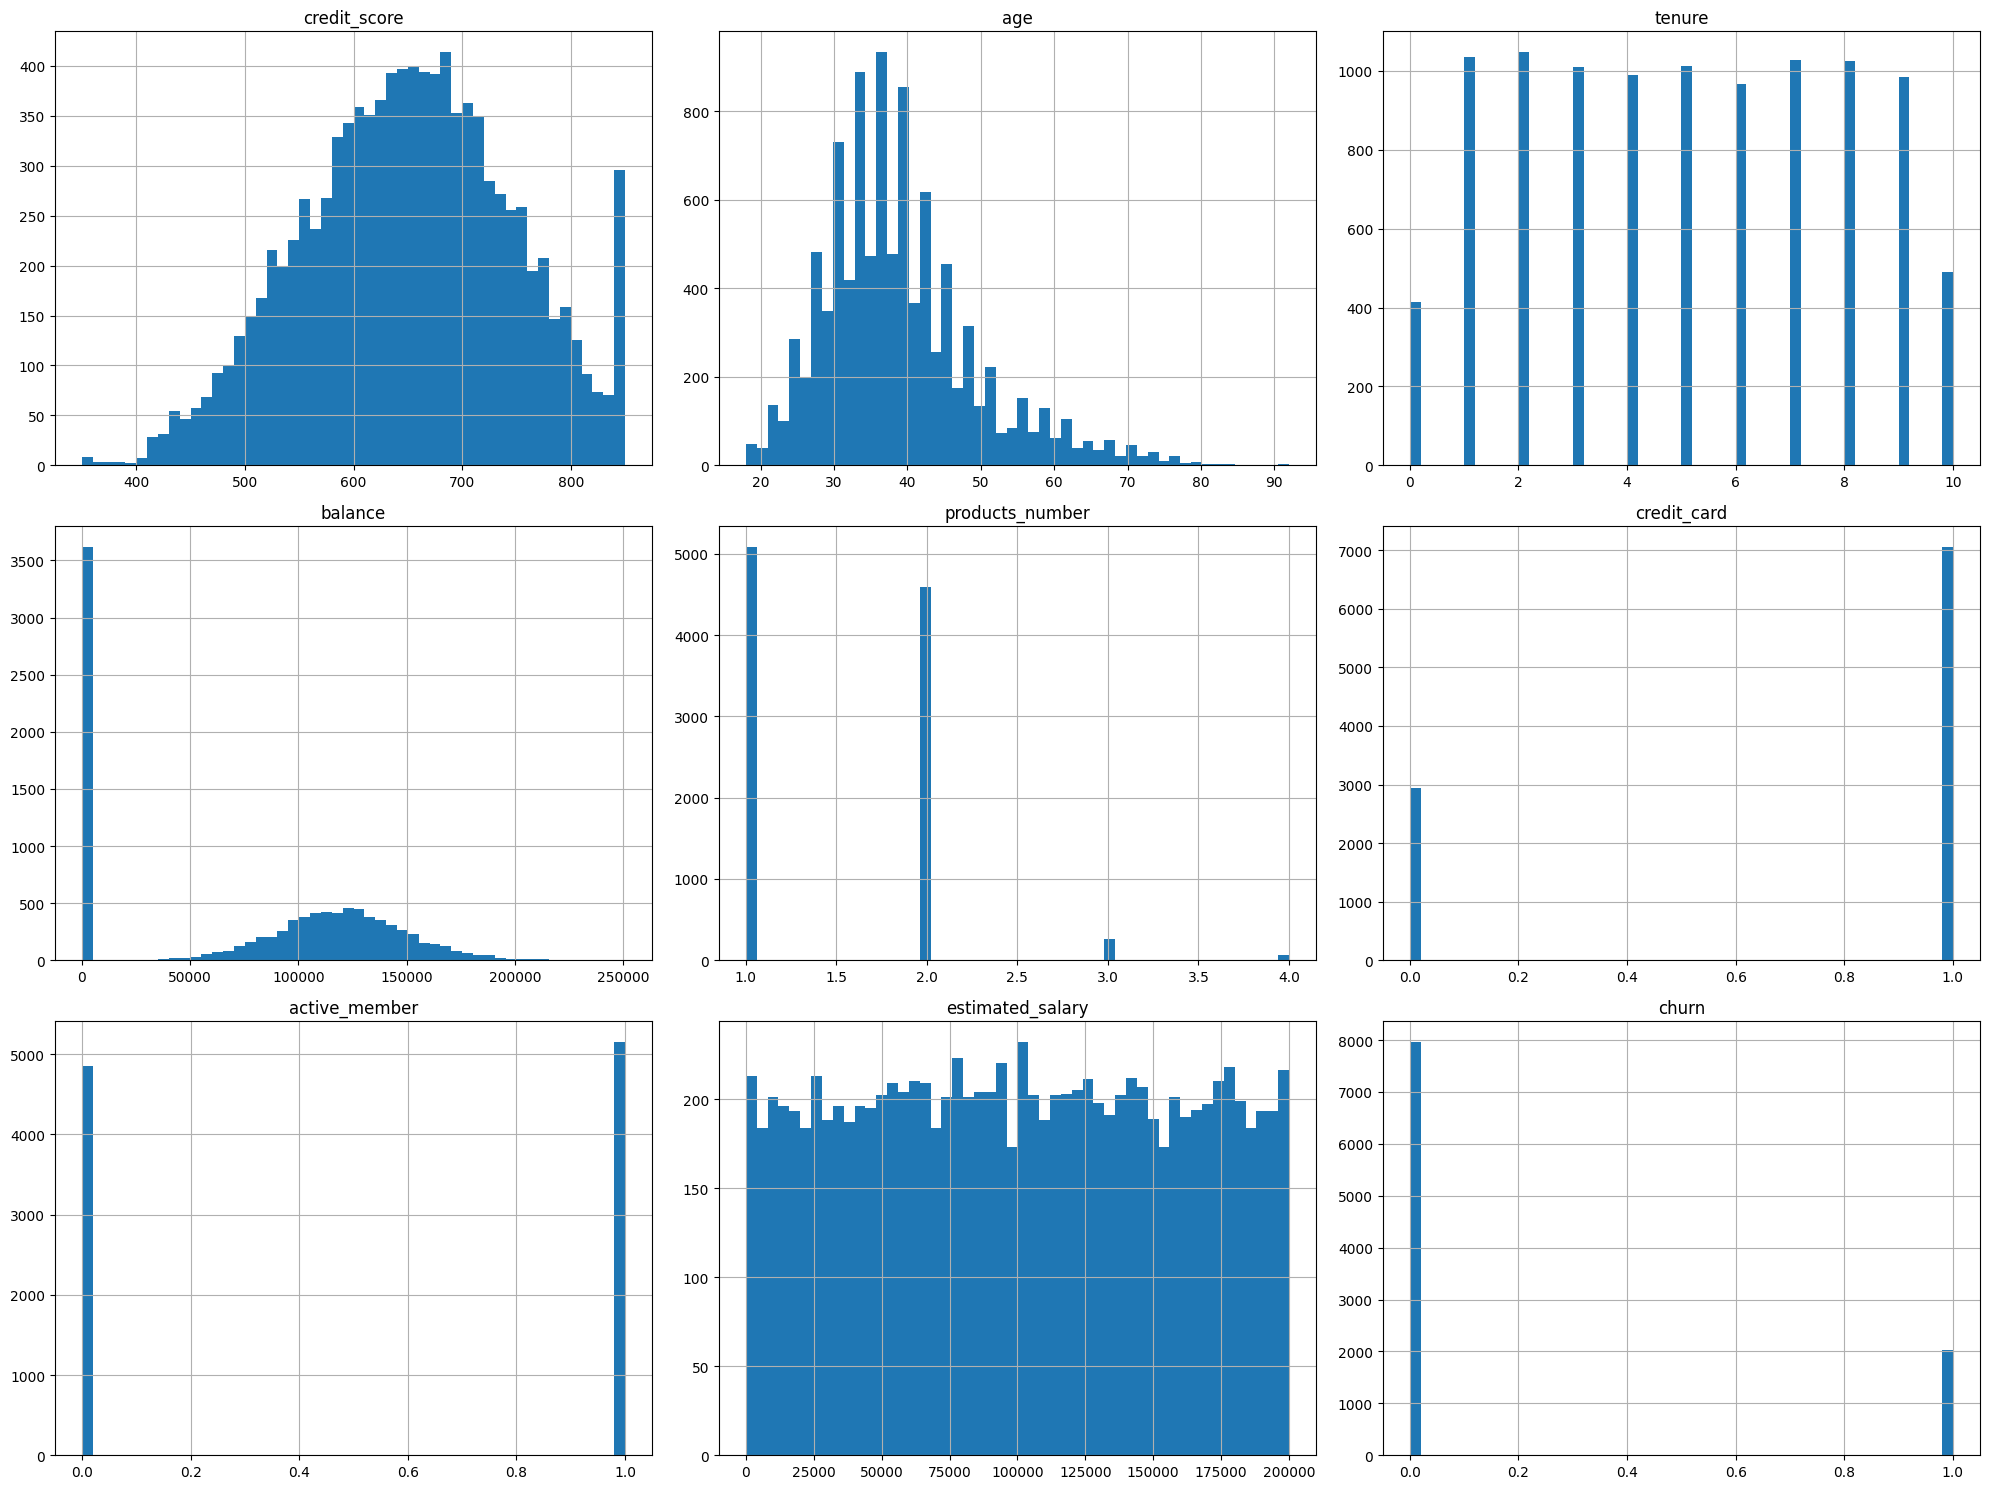

In [17]:
b_churn[b_churn.columns[1:]].hist(bins=50, figsize=(20, 15))
plt.tight_layout()
plt.show()

From these histograms: credit_score and age are skewed we can normalize them for model
stability and educe the impact of right-side tails. Also balance can be handled as
binary feature to separate customers with empty accounts from the rest,
as this is a distinct behavioral segment. Churn histogram is imbalanced.
If we split the data randomly into a training and test set,
there is a risk of sampling bias. So we need to save proportions-use stratified sampling

In [18]:


MULTI_CAT_FEATURES = ['country']

BIN_CAT_FEATURES = [
    'gender',
    'active_member',
    'credit_card'
]

NUMERICAL_FEATURES = [
    'age',
    'tenure',
    'balance',
    'products_number',
    'credit_score',
    'estimated_salary'
]
pipeline = ColumnTransformer([
    ("num", StandardScaler(), NUMERICAL_FEATURES),
    ("one-hot", OneHotEncoder(), MULTI_CAT_FEATURES),
    ("binary-cat", OrdinalEncoder(), BIN_CAT_FEATURES)
])
data_prepared = pipeline.fit_transform(b_churn)
data_prepared.shape

(10000, 12)

Gender is encoded as a binary feature (remains one column).
Country is encoded as a one-hot vector (making this 3 feature columns instead of 1).
Generally, scaling the features can be important.
Algorithms that use gradient descent for optimization (even a model as simple
as Logistic Regression) can benefit from scaling as this tends to result in faster
convergence.



---------------------------------------------------------------------------------------

Exploratory Data Analysis (EDA)

---------------------------------------------------------------------------------------

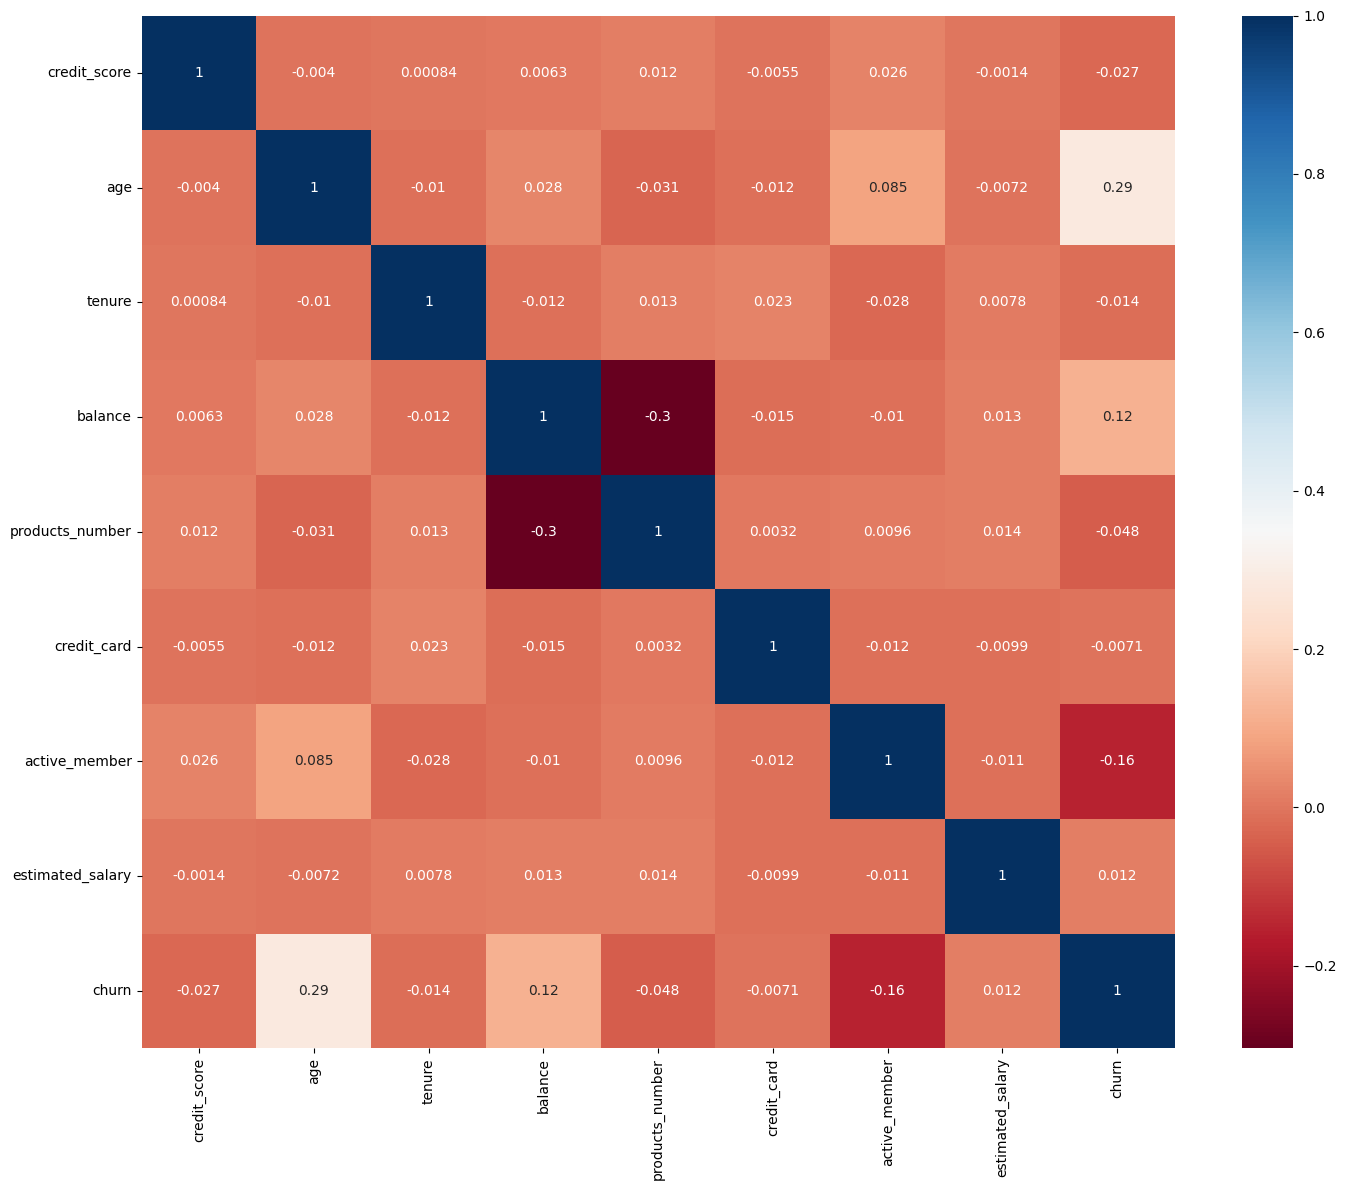

In [19]:
colormap = plt.cm.RdBu
sns.heatmap(b_churn.drop(['customer_id'], axis=1).corr(numeric_only=True), annot=True, cmap=colormap, square=True)
fig = plt.gcf()
fig.set_size_inches(15, 12)
plt.tight_layout()
plt.show()

From the correlation heatmap, we can identify which features are most related to churn:

age: 0.29  
strongest positive correlation, older customers are more likely to churn
active_member: -0.16  
strong negative correlation, inactive members are more likely to churn
balance: 0.12
moderate positive correlation, customers with higher balance tend to churn more
credit_score: 0.027
almost no correlation, credit score barely affects churn
tenure: -0.014
almost no correlation, how long a customer stays doesn't predict churn
estimated_salary: 0.012
almost no correlation, salary is not a useful churn predictor

Segments by country

In [20]:
churned_customers = b_churn[b_churn["churn"] == 1]
churn_percentage = churned_customers["country"].value_counts() / b_churn['country'].value_counts()
churn_percentage_df = pd.DataFrame({'Country': churn_percentage.index, 'churn percentage': churn_percentage.values})
churn_percentage_df

,Country,churn percentage
0,France,0.161548
1,Germany,0.324432
2,Spain,0.166734


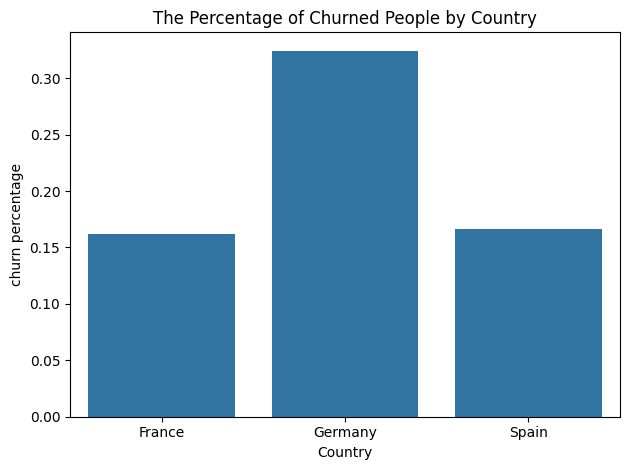

In [21]:
plt.title("The Percentage of Churned People by Country")
sns.barplot(x="Country",
            y="churn percentage",
            data=churn_percentage_df)
plt.tight_layout()
plt.show()

In [22]:
#Observation: People from Germany are more likely to churn

In [23]:
#Do female or male customers churn more? Does this differ by country?

In [24]:
churn_by_country_gender = b_churn.groupby(["country", "gender"]).agg(
    churn_amount=("churn", "sum")
).reset_index()
churn_by_country_gender


,country,gender,churn_amount
0,France,Female,460
1,France,Male,350
2,Germany,Female,448
3,Germany,Male,366
4,Spain,Female,231
5,Spain,Male,182


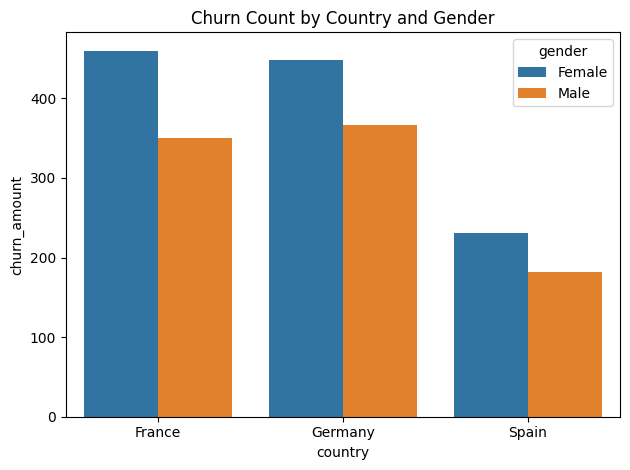

In [25]:
plt.title("Churn Count by Country and Gender")
sns.barplot(x="country", y="churn_amount", hue="gender", data=churn_by_country_gender)
plt.tight_layout()
plt.show()

In [26]:
# Observation: In all three countries, female customers churn more than male customers

In [27]:
#What is the average age of customers who churn vs. those who stay?

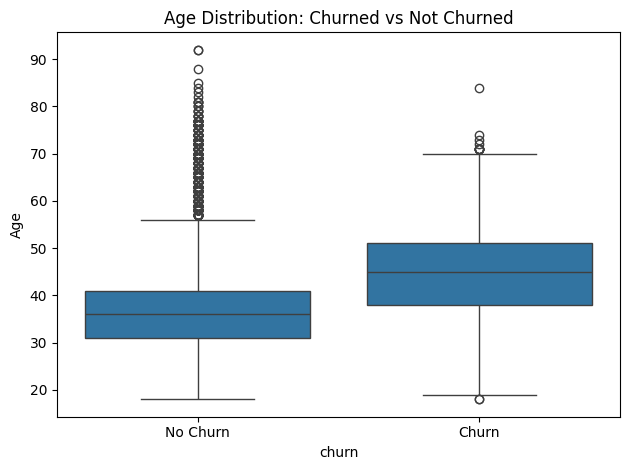

In [28]:
plt.title("Age Distribution: Churned vs Not Churned")
sns.boxplot(x="churn", y="age", data=b_churn)
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.ylabel("Age")
plt.tight_layout()
plt.show()

In [29]:
churned_mean_age = b_churn.groupby(["country", "gender"]).agg(
    mean_age=("age", "mean")
).reset_index()
churned_mean_age

,country,gender,mean_age
0,France,Female,38.773994
1,France,Male,38.296404
2,Germany,Female,40.154233
3,Germany,Male,39.424772
4,Spain,Female,39.199265
5,Spain,Male,38.649135


Observation:
In all countries, the average age of all customers is between 38 and 40.
This makes sense, since the heat map showed that age and churn
are correlated the most out of all the numerical features.

#Do customers with a higher balance tend to churn more?
Balance has a moderate correlation with churn (0.12).
Let's see if this holds across countries.

In [30]:
mean_balance_per_country_gender = b_churn.groupby(["country", "churn"]).agg(
    mean_balance=("balance", 'mean'))
mean_balance_per_country_gender = mean_balance_per_country_gender.reset_index()
mean_balance_per_country_gender

,country,churn,mean_balance
0,France,0,60339.275678
1,France,1,71192.795728
2,Germany,0,119427.106696
3,Germany,1,120361.075590
4,Spain,0,59678.070470
5,Spain,1,72513.352446


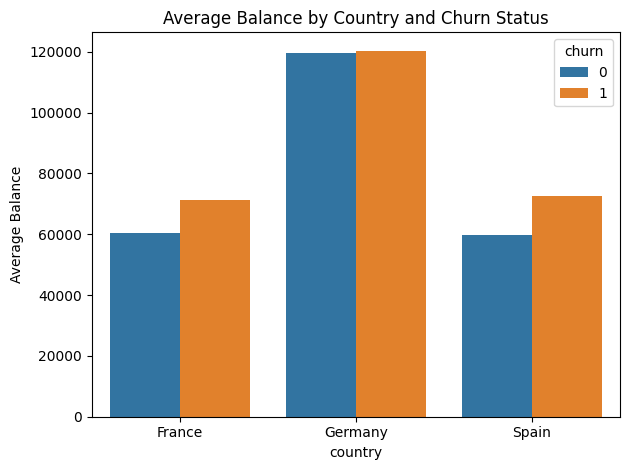

In [31]:
plt.title("Average Balance by Country and Churn Status")
sns.barplot(x="country", y="mean_balance", hue="churn", data=mean_balance_per_country_gender)
plt.ylabel("Average Balance")
plt.tight_layout()
plt.show()

Observation:
In France and Spain, churned customers have a higher average balance.
In Germany the average balance is almost identical between churned and non-churned customers,
meaning balance does NOT predict churn in Germany.
Germany's average balance is roughly twice that of France and Spain overall.

#Do active members churn less than inactive ones?
Active member has the second-strongest correlation with churn
(-0.16 is negative means active = less churn).

In [32]:
active_member_by_churn = b_churn.groupby(["churn", "active_member"]).agg(
    active_member_count=("active_member", 'count'))
active_member_by_churn = active_member_by_churn.reset_index()
active_member_by_churn

,churn,active_member,active_member_count
0,0,0,3547
1,0,1,4416
2,1,0,1302
3,1,1,735


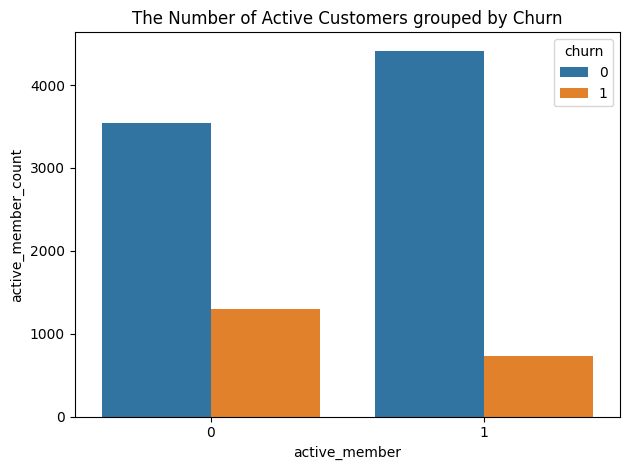

In [33]:
plt.title("The Number of Active Customers grouped by Churn")
sns.barplot(data=active_member_by_churn, x='active_member', y='active_member_count', hue='churn')
plt.tight_layout()
plt.show()

Observations:
Active members churn less than those who are inactive.

In [34]:
#Does the number of products a customer uses affect churn?

In [35]:
products_churn = b_churn.groupby("products_number").agg(
    total_customers=("churn", "count"),
    churned=("churn", "sum"),
    churn_rate=("churn", "mean")
).reset_index()
products_churn["churn_rate"] = products_churn["churn_rate"] * 100
products_churn

,products_number,total_customers,churned,churn_rate
0,1,5084,1409,27.714398
1,2,4590,348,7.581699
2,3,266,220,82.706767
3,4,60,60,100.000000


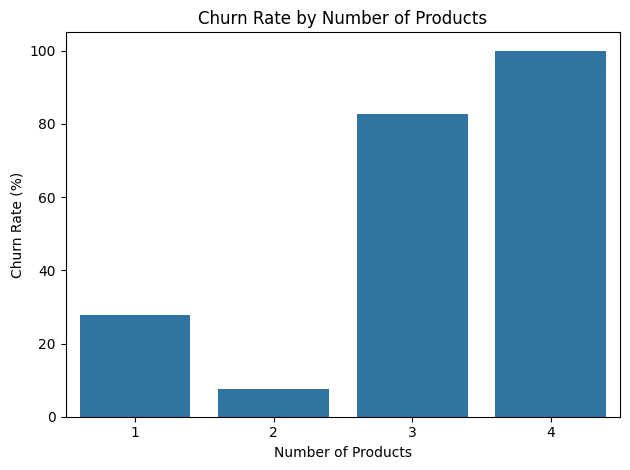

In [36]:
plt.title("Churn Rate by Number of Products")
sns.barplot(x="products_number", y="churn_rate", data=products_churn)
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

Observation:
Customers with 3 or 4 products have an extremely high churn rate
Customers with 1-2 products are the most stable


#Do customers with a credit card churn more or less?
Credit card ownership (credit_card) has very low correlation with churn (-0.007)

In [37]:
credit_card_by_churn = b_churn.groupby(["credit_card", "churn"]).agg(
    count=("credit_card", "count")
).reset_index()
total_per_group = b_churn.groupby("credit_card")["churn"].count().reset_index()
total_per_group.columns = ["credit_card", "total"]
credit_card_by_churn = credit_card_by_churn.merge(total_per_group, on="credit_card")
credit_card_by_churn["percentage"] = (credit_card_by_churn["count"] / credit_card_by_churn["total"]) * 100
credit_card_by_churn

,credit_card,churn,count,total,percentage
0,0,0,2332,2945,79.185059
1,0,1,613,2945,20.814941
2,1,0,5631,7055,79.815734
3,1,1,1424,7055,20.184266


Observation:
The churn rate is almost identical between customers who own a credit card (20.2%)
and those who do not (20.8%). This confirms that credit card ownership
has no meaningful impact on whether a customer churns or not.

#Does tenure affect churn?
Tenure shows very low correlation with churn (-0.014),
but long-term customers might behave differently.

In [38]:
avg_tenure = b_churn.groupby("churn").agg(mean_tenure=("tenure", "mean")).reset_index()
avg_tenure["churn"] = avg_tenure["churn"].map({0: "No Churn", 1: "Churn"})
avg_tenure

,churn,mean_tenure
0,No Churn,5.033279
1,Churn,4.932744


Observation:
Average tenure is almost identical for churned and non-churned customers
Tenure alone is NOT a useful predictor of churn

#Is estimated salary related to churn?
Salary has almost zero correlation with churn (0.012)

In [39]:
churned_mean_income = b_churn.groupby(["country", "churn"]).agg(mean_estimated_income=("estimated_salary", 'mean'))
churned_mean_income = churned_mean_income.reset_index()
churned_mean_income

,country,churn,mean_estimated_income
0,France,0,99217.097331
1,France,1,103439.278296
2,Germany,0,102414.657876
3,Germany,1,98403.886450
4,Spain,0,98602.369864
5,Spain,1,103629.554818


Observation:
Salary shows almost no difference between churned and retained customers
across all three countries, which means that it is NOT a reliable churn predictor

#Does credit score differ between churned and retained customers?
Credit score has a very weak correlation (-0.027)

In [40]:
avg_credit = b_churn.groupby(["country", "gender", "churn"]).agg(
    mean_credit_score=("credit_score", "mean")
).reset_index()
avg_credit["churn"] = avg_credit["churn"].map({0: "No Churn", 1: "Churn"})
avg_credit

,country,gender,churn,mean_credit_score
0,France,Female,No Churn,650.536369
1,France,Female,Churn,643.897826
2,France,Male,No Churn,651.631294
3,France,Male,Churn,639.308571
4,Germany,Female,No Churn,654.514094
5,Germany,Female,Churn,650.732143
6,Germany,Male,No Churn,652.278947
7,Germany,Male,Churn,643.964481
8,Spain,Female,No Churn,653.494172
9,Spain,Female,Churn,645.363636


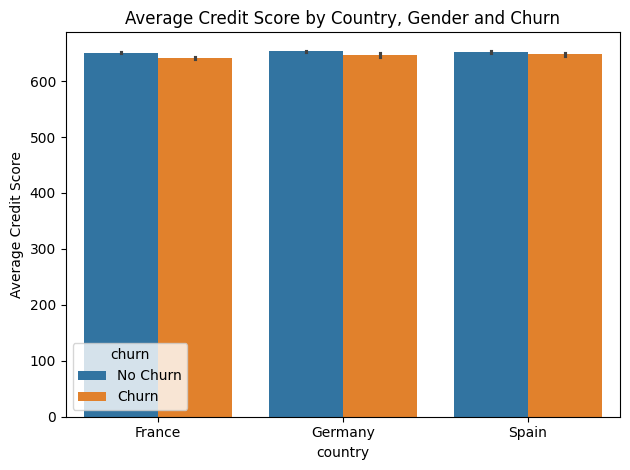

In [41]:
plt.title("Average Credit Score by Country, Gender and Churn")
sns.barplot(x="country", y="mean_credit_score", hue="churn", data=avg_credit)
plt.ylabel("Average Credit Score")
plt.tight_layout()
plt.show()

Observation:
Credit score is nearly identical across churned and non-churned customers
in all countries and genders, so this feature doesnt have an impact on crunch

Based on everything we found in the EDA:

Analysis Conclusions:

- Customers in Germany are most likely to churn, with a churn rate of roughly
  twice that of France and Spain.
  
- Age is the strongest predictor of churn — churned customers are on average
  older (43-45) than those who stay.
  
- Inactive members churn significantly more than active ones — being engaged
  with the bank is a strong sign a customer will stay.
  
- In France and Spain, customers with a higher balance tend to leave more often.
  In Germany, balance makes almost no difference.
  
- In all three countries, female customers churn more than male customers.

- Estimated salary and credit score show almost no difference between churned
  and retained customers — they are not useful predictors of churn.
  
- Credit card ownership has no meaningful impact on churn — the churn rate is
  almost identical with or without a credit card (~20%).
  
- Tenure does not predict churn — customers who have been with the bank for
  a long time are just as likely to leave as newer customers.
  
- Customers with 3 or 4 products have a surprisingly high churn rate compared
  to those with 1 or 2 products.

----------------------------------------------------------------------------------------

Feature Engineering

---------------------------------------------------------------------------------------

In [42]:
def tenure_group(t):
    if t <= 2:
        return '0-2 years'
    elif t <= 5:
        return '3-5 years'
    else:
        return '6+ years'

b_churn['tenure_group'] = b_churn['tenure'].apply(tenure_group)
b_churn['customer_value'] = b_churn['balance'] * b_churn['tenure']
b_churn['activity_rate'] = b_churn['balance'] / (b_churn['tenure'] + 1)

b_churn['is_multi_product_customer'] = (b_churn['products_number'] > 1).astype(int)
b_churn['high_risk_products'] = (b_churn['products_number'] >= 3).astype(int)
b_churn['zero_balance'] = (b_churn['balance'] == 0).astype(int)
b_churn['age_activity_score'] = b_churn['age'] * (1 - b_churn['active_member'])

In [43]:
from sklearn.metrics import average_precision_score, roc_auc_score

def compare_dataset(df, target_col, feature_cols, models):
    data = df[feature_cols + [target_col]].copy()

    text_cols = data.select_dtypes(include='object').columns.tolist()
    data = pd.get_dummies(data, columns=text_cols, drop_first=True)

    X = data.drop(target_col, axis=1)
    y = data[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    results = []
    for name, mp in models.items():
        model = mp['model']
        model.fit(X_train_scaled, y_train)
        pred = model.predict_proba(X_test_scaled)[:, 1]
        results.append({
            'model': name,
            'ap': round(average_precision_score(y_test, pred), 4),
            'roc_auc': round(roc_auc_score(y_test, pred), 4)
        })

    return pd.DataFrame(results)

In [44]:
model_params = {
    'xgboost': {'model': XGBClassifier(random_state=42)},
    'random_forest': {'model': RandomForestClassifier(random_state=42)},
    'logistic_regression': {'model': LogisticRegression(solver='liblinear')}
}

In [45]:
features_v1 = ['age','tenure','balance','products_number','credit_score',
               'estimated_salary','gender','active_member','credit_card','country']

result_v1 = compare_dataset(b_churn, 'churn', features_v1, model_params)
result_v1

,model,ap,roc_auc
0,xgboost,0.6651,0.8333
1,random_forest,0.6796,0.8483
2,logistic_regression,0.4790,0.7748


In [46]:
features_v2 = features_v1 + ['is_multi_product_customer', 'tenure_group', 'customer_value', 'activity_rate']
result_v2 = compare_dataset(b_churn, 'churn', features_v2, model_params)
result_v2

,model,ap,roc_auc
0,xgboost,0.6652,0.8335
1,random_forest,0.6807,0.8443
2,logistic_regression,0.6327,0.8370


In [47]:
features_v3 = features_v1 + ['is_multi_product_customer', 'high_risk_products', 'zero_balance', 'age_activity_score']

result_v3 = compare_dataset(b_churn, 'churn', features_v3, model_params)
result_v3

,model,ap,roc_auc
0,xgboost,0.6667,0.8360
1,random_forest,0.6824,0.8520
2,logistic_regression,0.6711,0.8398


In [48]:
final_columns = [
    'age', 'tenure', 'balance', 'products_number', 'credit_score', 'estimated_salary',
    'gender', 'active_member', 'credit_card', 'country',
    'is_multi_product_customer', 'high_risk_products', 'zero_balance', 'age_activity_score',
    'churn'
]
b_churn = b_churn[final_columns]
b_churn.head()

,age,tenure,balance,products_number,credit_score,estimated_salary,gender,active_member,credit_card,country,is_multi_product_customer,high_risk_products,zero_balance,age_activity_score,churn
0,42,2,0.00,1,619,101348.88,Female,1,1,France,0,0,1,0,1
1,41,1,83807.86,1,608,112542.58,Female,1,0,Spain,0,0,0,0,0
2,42,8,159660.80,3,502,113931.57,Female,0,1,France,1,1,0,42,1
3,39,1,0.00,2,699,93826.63,Female,0,0,France,1,0,1,39,0
4,43,2,125510.82,1,850,79084.10,Female,1,1,Spain,0,0,0,0,0


In [49]:
MULTI_CAT_FEATURES = ['country']

BIN_CAT_FEATURES = [
    'gender',
    'active_member',
    'credit_card',
    'is_multi_product_customer',
    'high_risk_products',
    'zero_balance'
]

NUMERICAL_FEATURES = [
    'age', 'tenure', 'balance', 'products_number',
    'credit_score', 'estimated_salary',
    'age_activity_score'
]

In [50]:
X = b_churn[NUMERICAL_FEATURES + MULTI_CAT_FEATURES + BIN_CAT_FEATURES]
y = b_churn['churn']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [52]:
pipeline = ColumnTransformer([
    ("num", StandardScaler(), NUMERICAL_FEATURES),
    ("one-hot", OneHotEncoder(handle_unknown='ignore'), MULTI_CAT_FEATURES),
    ("binary-cat", OrdinalEncoder(), BIN_CAT_FEATURES)
])

X_train_prepared = pipeline.fit_transform(X_train)
X_test_prepared = pipeline.transform(X_test)

X_train_prepared.shape, X_test_prepared.shape

((8000, 16), (2000, 16))

**tenure_group:** We grouped customers by how long they have been with the bank. This helps the model treat new and long term customers differently instead of using raw numbers.

**customer_value:** Customers with high balance and long tenure are more valuable to the bank. This feature captures both at once.

**activity_rate:** Balance divided by tenure tells us how financially active a customer is per year relative to how long they stayed.

**is_multi_product_customer:** A binary flag marking customers with more than one product, used to capture relationship depth with the bank.

**high_risk_products:** EDA showed that customers with 3 or 4 products churn at an extremely high rate (over 80%), far higher than customers with 1 or 2 products. This flag isolates that small, high-risk segment so the model can react to it directly.

**zero_balance:** EDA showed customers with a zero balance churn noticeably less than customers with a positive balance. This flag captures that distinct behavior pattern, which a continuous balance feature alone does not fully express.

**age_activity_score:** EDA showed that older age and inactivity are both strong churn signals. We combined them into one feature so the model can catch customers who are both older and inactive at the same time.

----------------------------------------------------------------------------------------

Model Building/Evaluation Metrics

----------------------------------------------------------------------------------------

In [53]:
def display_evaluation(classifier_model, X, y, threshold=0.5):
    y_proba = classifier_model.predict_proba(X)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    accuracy = round(accuracy_score(y, y_pred)*100, 2)
    precision = round(precision_score(y, y_pred)*100, 2)
    recall = round(recall_score(y, y_pred)*100, 2)
    f1 = round(f1_score(y, y_pred)*100, 2)
    auc = round(roc_auc_score(y, y_proba)*100, 2)

    print(classification_report(y, y_pred))
    print('Accuracy:', accuracy)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1-score:', f1)
    print('AUC:', auc)

    ConfusionMatrixDisplay.from_estimator(classifier_model, X, y)
    plt.show()

    precision_vals, recall_vals, _ = precision_recall_curve(y, y_proba)
    plt.plot(recall_vals, precision_vals)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.show()

    df_lift = pd.DataFrame({'y_true': y, 'y_pred': y_proba})
    df_lift = df_lift.sort_values('y_pred', ascending=False).reset_index(drop=True)
    df_lift['cumulative_churn'] = df_lift['y_true'].cumsum() / df_lift['y_true'].sum()
    df_lift['cumulative_population'] = (df_lift.index + 1) / len(df_lift)

    plt.plot(df_lift['cumulative_population'], df_lift['cumulative_churn'])
    plt.plot([0,1], [0,1])
    plt.xlabel('% of Customers Contacted')
    plt.ylabel('% of Churners Captured')
    plt.title('Gains Chart')
    plt.show()

In [54]:
#Logistic regression

              precision    recall  f1-score   support

           0       0.90      0.89      0.90      1593
           1       0.60      0.63      0.61       407

    accuracy                           0.84      2000
   macro avg       0.75      0.76      0.76      2000
weighted avg       0.84      0.84      0.84      2000

Accuracy: 83.9
Precision: 59.95
Recall: 62.9
F1-score: 61.39
AUC: 84.03


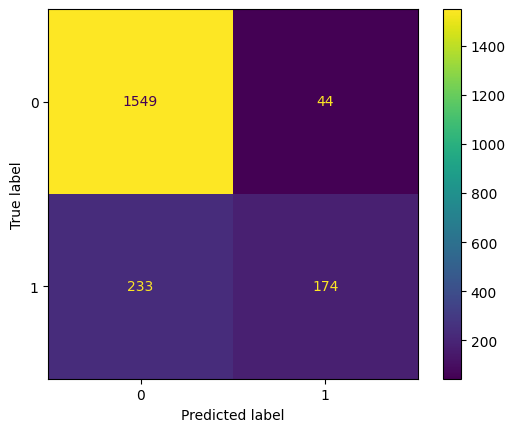

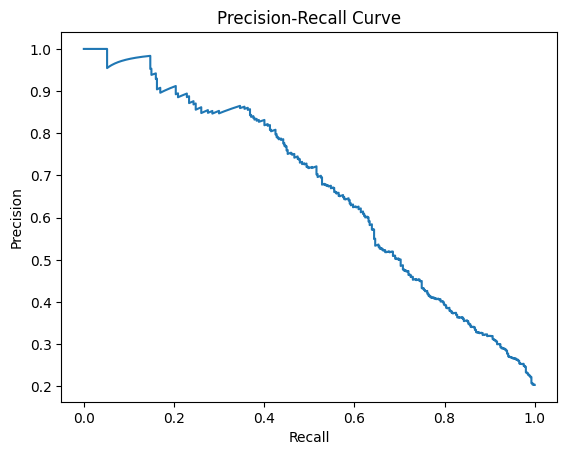

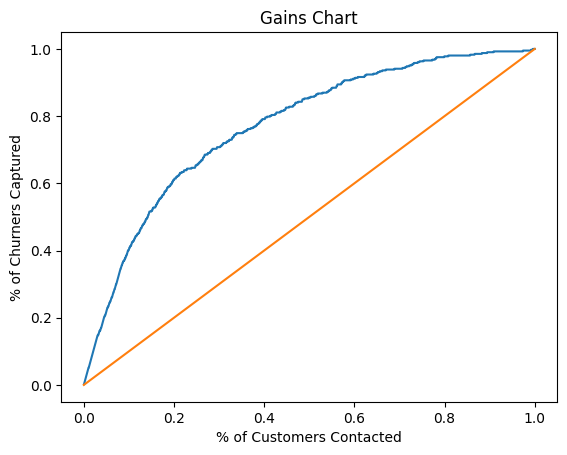

In [55]:
log_model = LogisticRegression(solver='liblinear')
log_model.fit(X_train_prepared, y_train)
display_evaluation(log_model, X_test_prepared, y_test, 0.3)

In [56]:
#Random Forest Classifier

              precision    recall  f1-score   support

           0       0.91      0.86      0.89      1593
           1       0.55      0.68      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.77      0.75      2000
weighted avg       0.84      0.82      0.83      2000

Accuracy: 82.3
Precision: 55.27
Recall: 68.3
F1-score: 61.1
AUC: 85.21


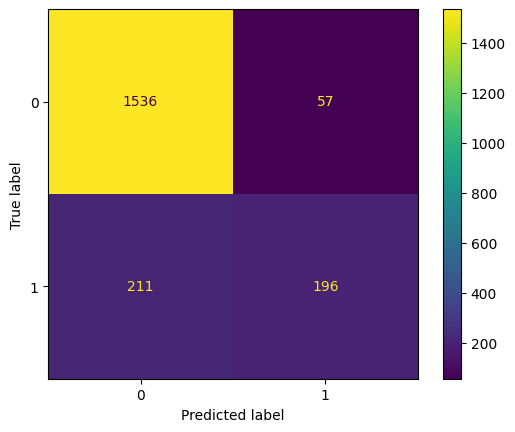

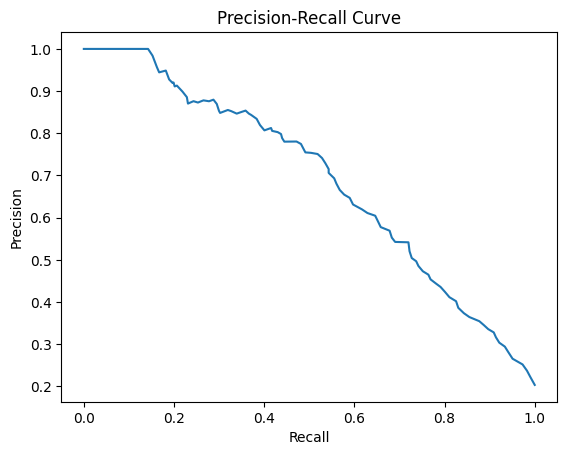

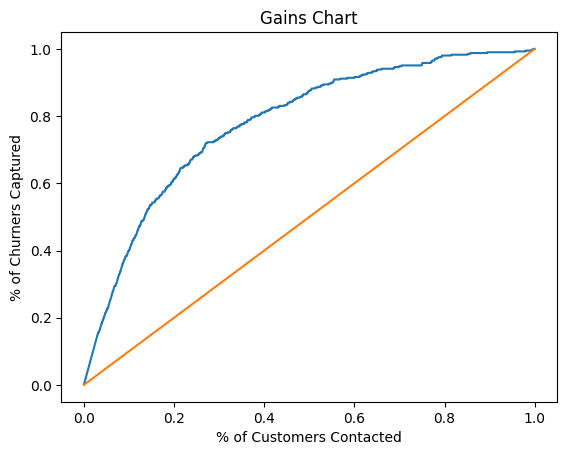

In [57]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_prepared, y_train)
display_evaluation(rf_model, X_test_prepared, y_test, 0.3)

In [58]:
#XGBoost Classifier

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1593
           1       0.57      0.62      0.59       407

    accuracy                           0.83      2000
   macro avg       0.73      0.75      0.74      2000
weighted avg       0.83      0.83      0.83      2000

Accuracy: 82.7
Precision: 56.88
Recall: 61.92
F1-score: 59.29
AUC: 83.84


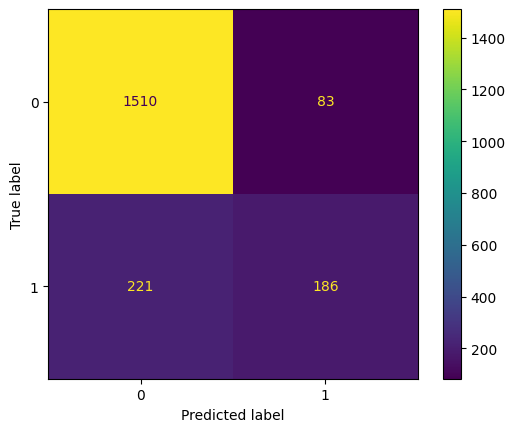

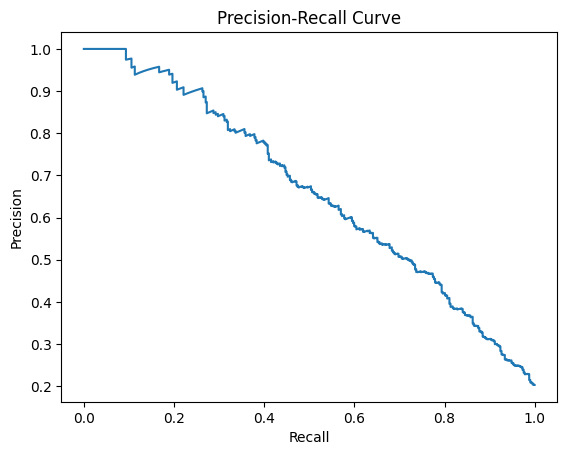

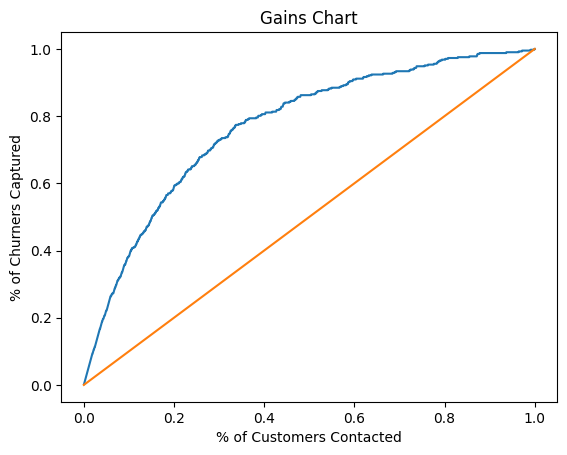

In [59]:
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_prepared, y_train)
display_evaluation(xgb_model, X_test_prepared, y_test,0.3)

---------------------------------------------------------------------------------------

Model Tuning

---------------------------------------------------------------------------------------

In [60]:
model_params = {
    'xgboost': {
        'model': XGBClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5]
        }
    },
    'random_forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [10, 20],
            'min_samples_leaf': [1, 2]
        }
    },
    'logistic_regression': {
        'model': LogisticRegression(solver='liblinear'),
        'params': {
            'C': [1, 5, 10]
        }
    }
}

scores = []
for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv=3, scoring='average_precision', return_train_score=False)
    clf.fit(X_train_prepared, y_train)
    scores.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
df = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
df

,model,best_score,best_params
0,xgboost,0.703774,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
1,random_forest,0.699939,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es..."
2,logistic_regression,0.654711,{'C': 10}


In [61]:
#Лучше лишний раз обзвонить клиента чем дать ему уйти

---------------------------------------------------------------------------------------

Model Explainability

---------------------------------------------------------------------------------------

In [62]:
#Logistic Regression

                                  feature  coefficient
13  binary-cat__is_multi_product_customer    -3.411651
11              binary-cat__active_member     2.538044
14         binary-cat__high_risk_products     2.149406
6                 num__age_activity_score     1.727505
3                    num__products_number     1.091622
7                 one-hot__country_France    -0.658702
9                  one-hot__country_Spain    -0.574515
10                     binary-cat__gender    -0.498005
0                                num__age     0.400319
8                one-hot__country_Germany     0.344092
15               binary-cat__zero_balance     0.294086
12                binary-cat__credit_card    -0.108292
2                            num__balance     0.080485
4                       num__credit_score    -0.074961
5                   num__estimated_salary     0.037688
1                             num__tenure    -0.027062


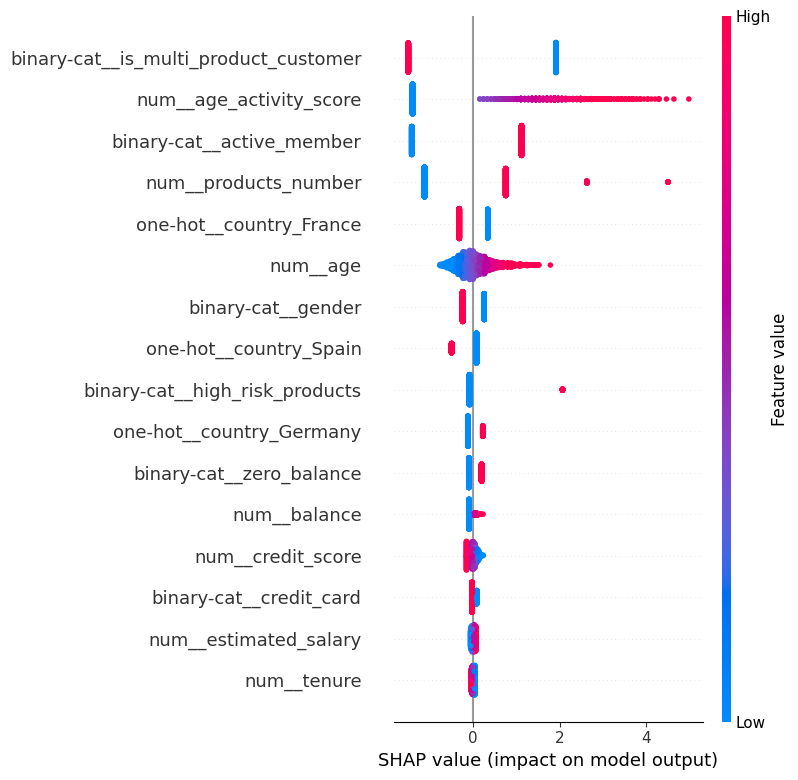

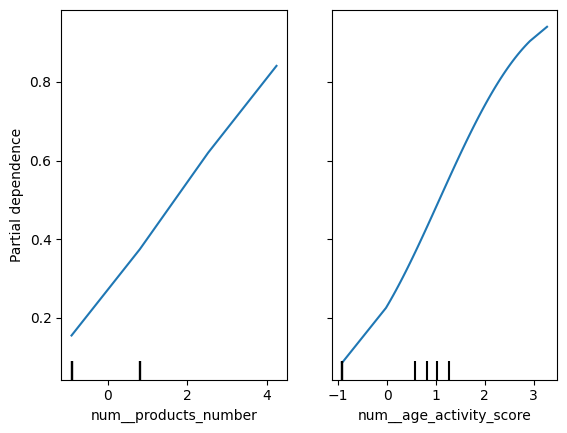

In [63]:
feature_names = pipeline.get_feature_names_out()

log_reg = LogisticRegression(solver='liblinear')
log_reg.fit(X_train_prepared, y_train)

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
print(coef_df)

explainer_lr = shap.LinearExplainer(log_reg, X_train_prepared)
shap_values_lr = explainer_lr.shap_values(X_test_prepared)
shap.summary_plot(shap_values_lr, X_test_prepared, feature_names=feature_names)

pdp_features = ['num__products_number', 'num__age_activity_score']
pdp_idx = [list(feature_names).index(f) for f in pdp_features]
PartialDependenceDisplay.from_estimator(log_reg, X_train_prepared, features=pdp_idx, feature_names=feature_names)

In [64]:
#Random Forest

                                  feature  importance
0                                num__age    0.153459
6                 num__age_activity_score    0.140488
5                   num__estimated_salary    0.133058
4                       num__credit_score    0.130454
2                            num__balance    0.123324
1                             num__tenure    0.076913
3                    num__products_number    0.063952
14         binary-cat__high_risk_products    0.042044
13  binary-cat__is_multi_product_customer    0.026356
8                one-hot__country_Germany    0.020723
10                     binary-cat__gender    0.019160
12                binary-cat__credit_card    0.018599
11              binary-cat__active_member    0.016950
15               binary-cat__zero_balance    0.012464
7                 one-hot__country_France    0.011770
9                  one-hot__country_Spain    0.010285


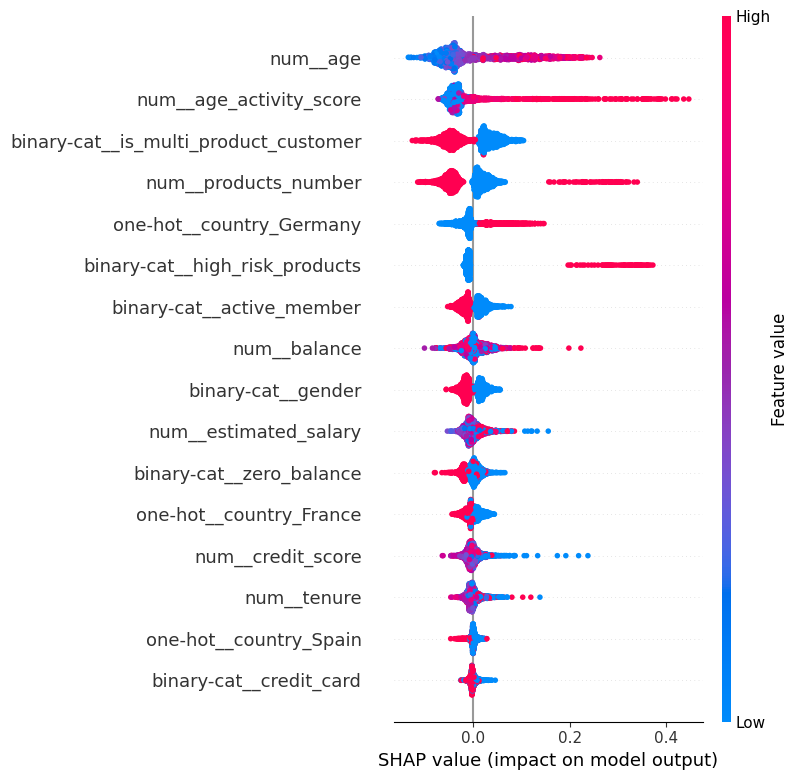

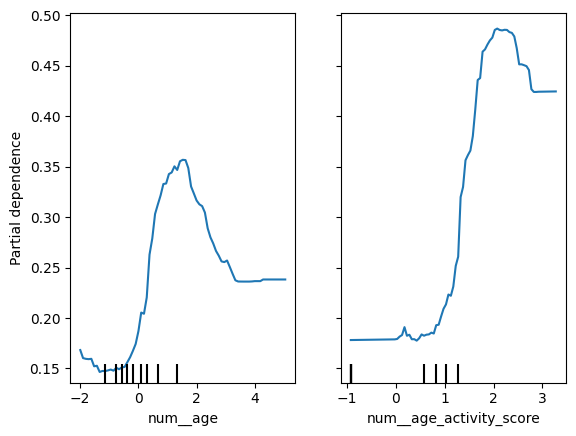

In [65]:
rf = RandomForestClassifier(random_state=42, n_estimators=200)
rf.fit(X_train_prepared, y_train)

importance_df_rf = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(importance_df_rf)

explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test_prepared)
shap.summary_plot(shap_values_rf[:, :, 1], X_test_prepared, feature_names=feature_names)

pdp_features = ['num__age', 'num__age_activity_score']
pdp_idx = [list(feature_names).index(f) for f in pdp_features]
PartialDependenceDisplay.from_estimator(rf, X_train_prepared, features=pdp_idx, feature_names=feature_names)

In [66]:
#XGBoost

                                  feature  importance
3                    num__products_number    0.251512
6                 num__age_activity_score    0.167614
15               binary-cat__zero_balance    0.133783
8                one-hot__country_Germany    0.098079
0                                num__age    0.065443
2                            num__balance    0.047378
10                     binary-cat__gender    0.042438
7                 one-hot__country_France    0.038699
9                  one-hot__country_Spain    0.036084
5                   num__estimated_salary    0.030945
4                       num__credit_score    0.030764
1                             num__tenure    0.030147
12                binary-cat__credit_card    0.027112
11              binary-cat__active_member    0.000000
13  binary-cat__is_multi_product_customer    0.000000
14         binary-cat__high_risk_products    0.000000


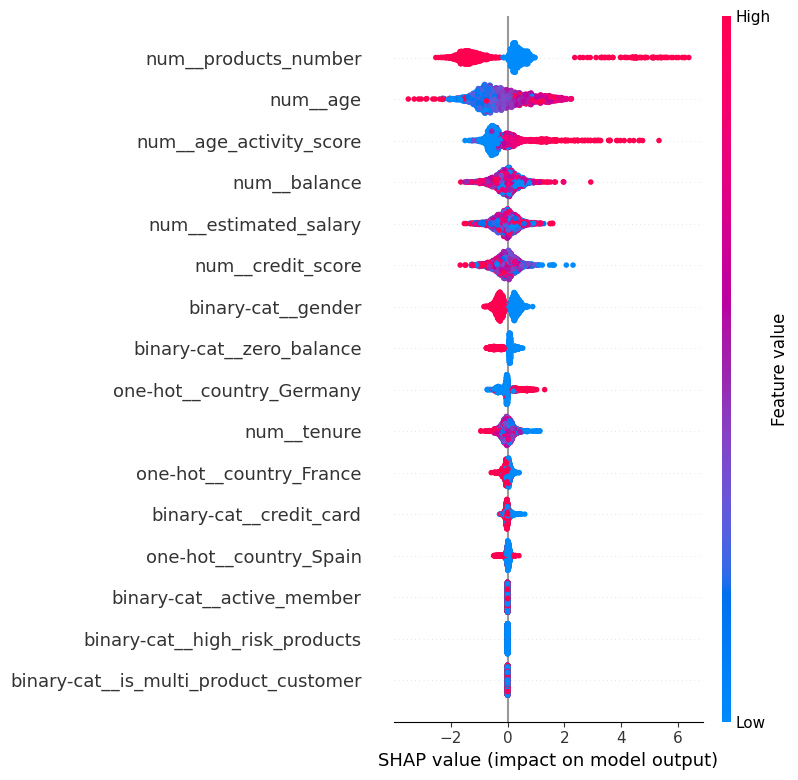

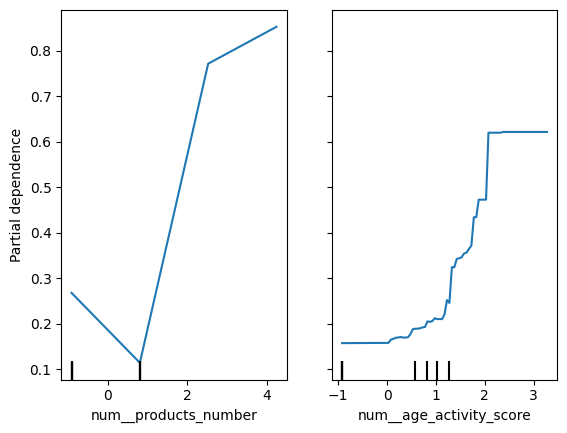

In [67]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_prepared, y_train)

importance_df_xgb = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)
print(importance_df_xgb)

explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test_prepared)
shap.summary_plot(shap_values_xgb, X_test_prepared, feature_names=feature_names)

pdp_features = ['num__products_number', 'num__age_activity_score']
pdp_idx = [list(feature_names).index(f) for f in pdp_features]
PartialDependenceDisplay.from_estimator(xgb, X_train_prepared, features=pdp_idx, feature_names=feature_names)

In [71]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

logistic = LogisticRegression(penalty='l2', random_state=42, max_iter=1000)
logistic.fit(X_train_prepared, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_prepared, y_train)

xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_prepared, y_train)

models = {
    'Logistic Regression': logistic,
    'Random Forest': rf,
    'XGBoost': xgb
}

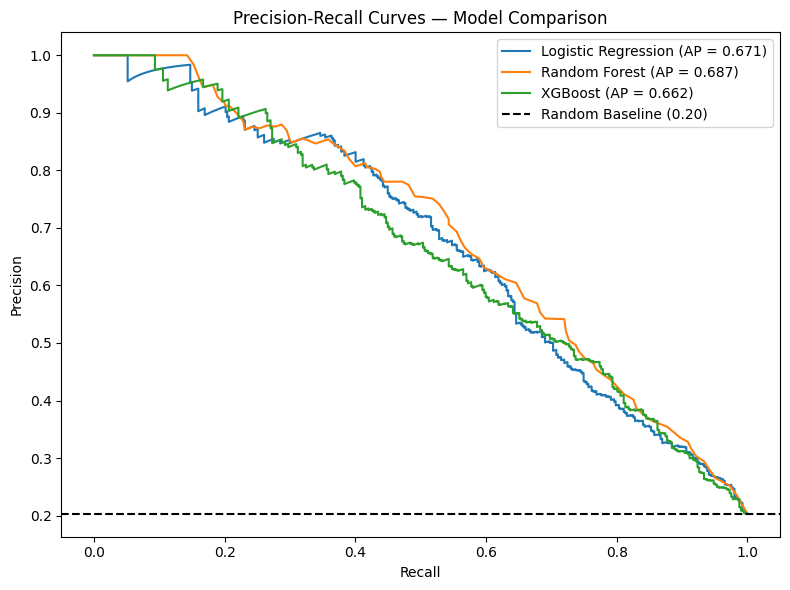

In [72]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test_prepared)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.3f})')

baseline = y_test.mean()
plt.axhline(y=baseline, color='k', linestyle='--', label=f'Random Baseline ({baseline:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

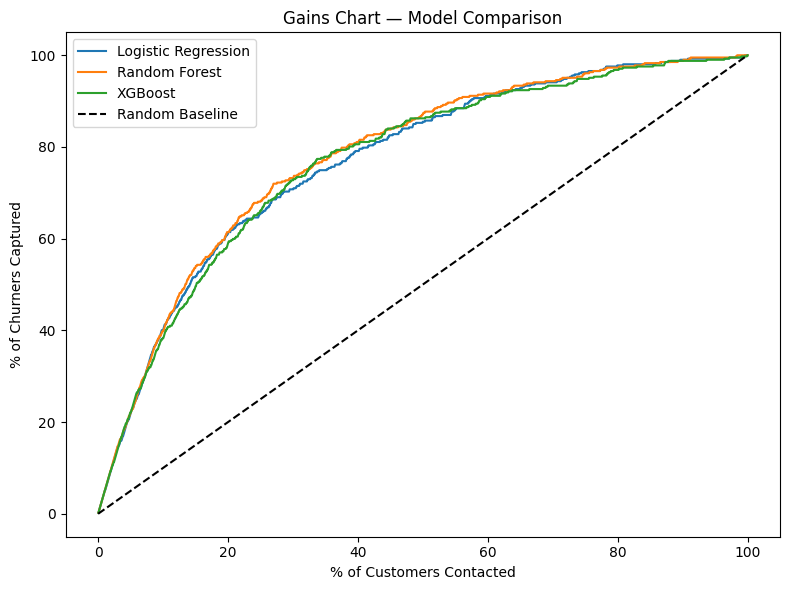

In [73]:
import numpy as np

plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test_prepared)[:, 1]
    sorted_idx = np.argsort(y_prob)[::-1]
    y_sorted = np.array(y_test)[sorted_idx]

    gains = np.cumsum(y_sorted) / y_sorted.sum()
    pct_contacted = np.arange(1, len(y_sorted) + 1) / len(y_sorted)

    plt.plot(pct_contacted * 100, gains * 100, label=name)

plt.plot([0, 100], [0, 100], 'k--', label='Random Baseline')
plt.xlabel('% of Customers Contacted')
plt.ylabel('% of Churners Captured')
plt.title('Gains Chart — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

ROC-AUC: 0.8540

--- Strategy comparison (same 25% budget) ---
                Churn Reduction  Contacts (#)  Cost ($)  Avg Balance ($)  Avg Churn Proba  Retained Value ($)  Net Benefit ($)      ROI  Precision@K  Recall@K
Strategy                                                                                                                                                      
Top VaR                     20%           500     25000         129147.0            0.479           5963742.0        5938742.0  237.550        0.470     0.577
Top Proba                   18%           500     25000          91948.0            0.559           4621669.0        4596669.0  183.867        0.558     0.686
Top Uncertainty             35%           500     25000         133061.0            0.358           8191922.0        8166922.0  326.677        0.348     0.428
Mixed                       27%           500     25000         132960.0            0.464           8005468.0        7980468.0  319.219       

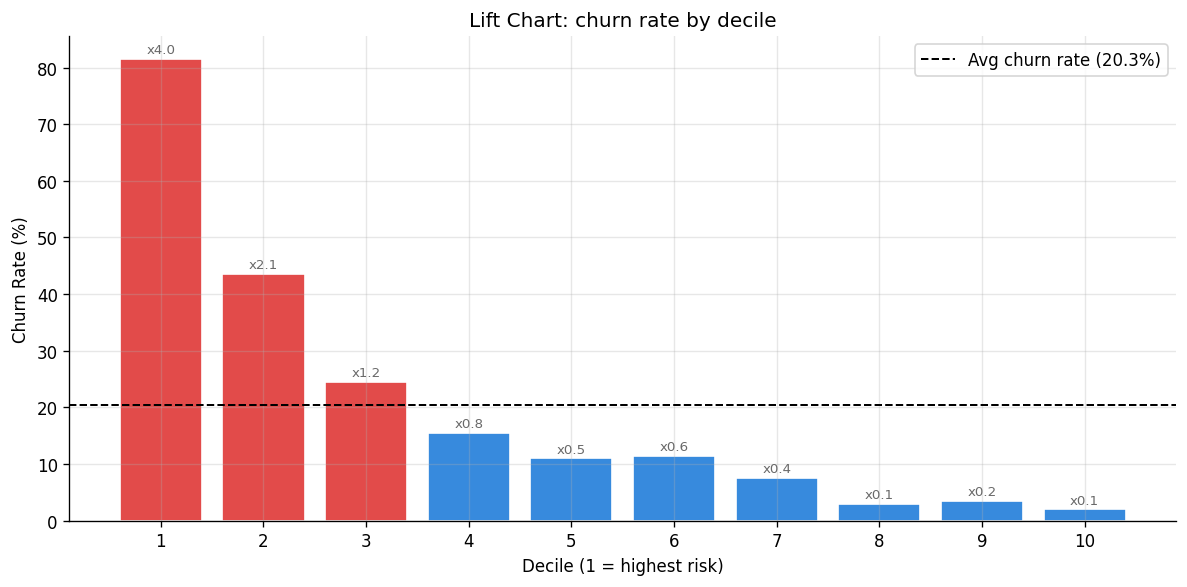

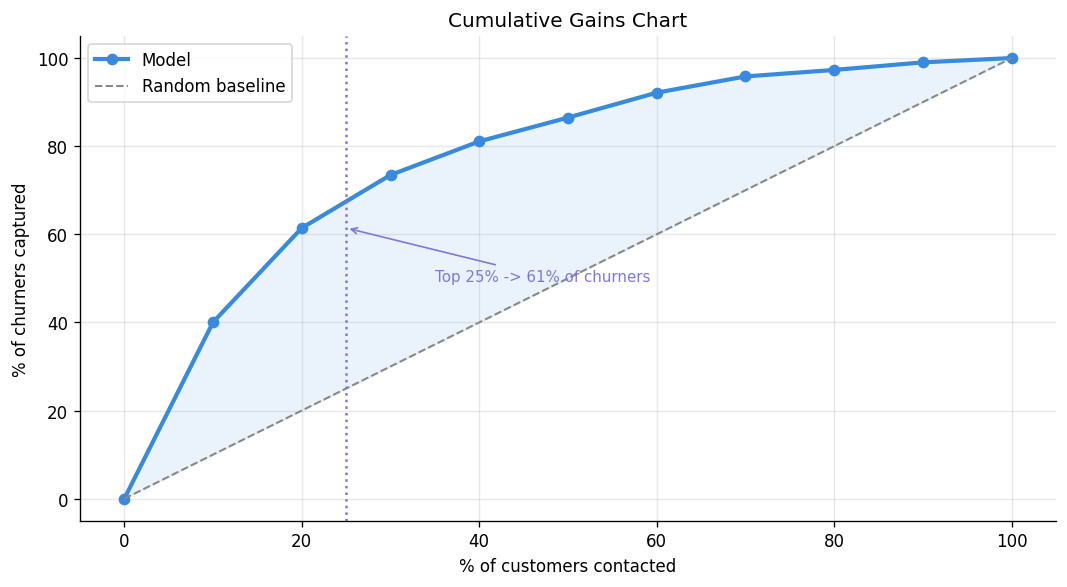

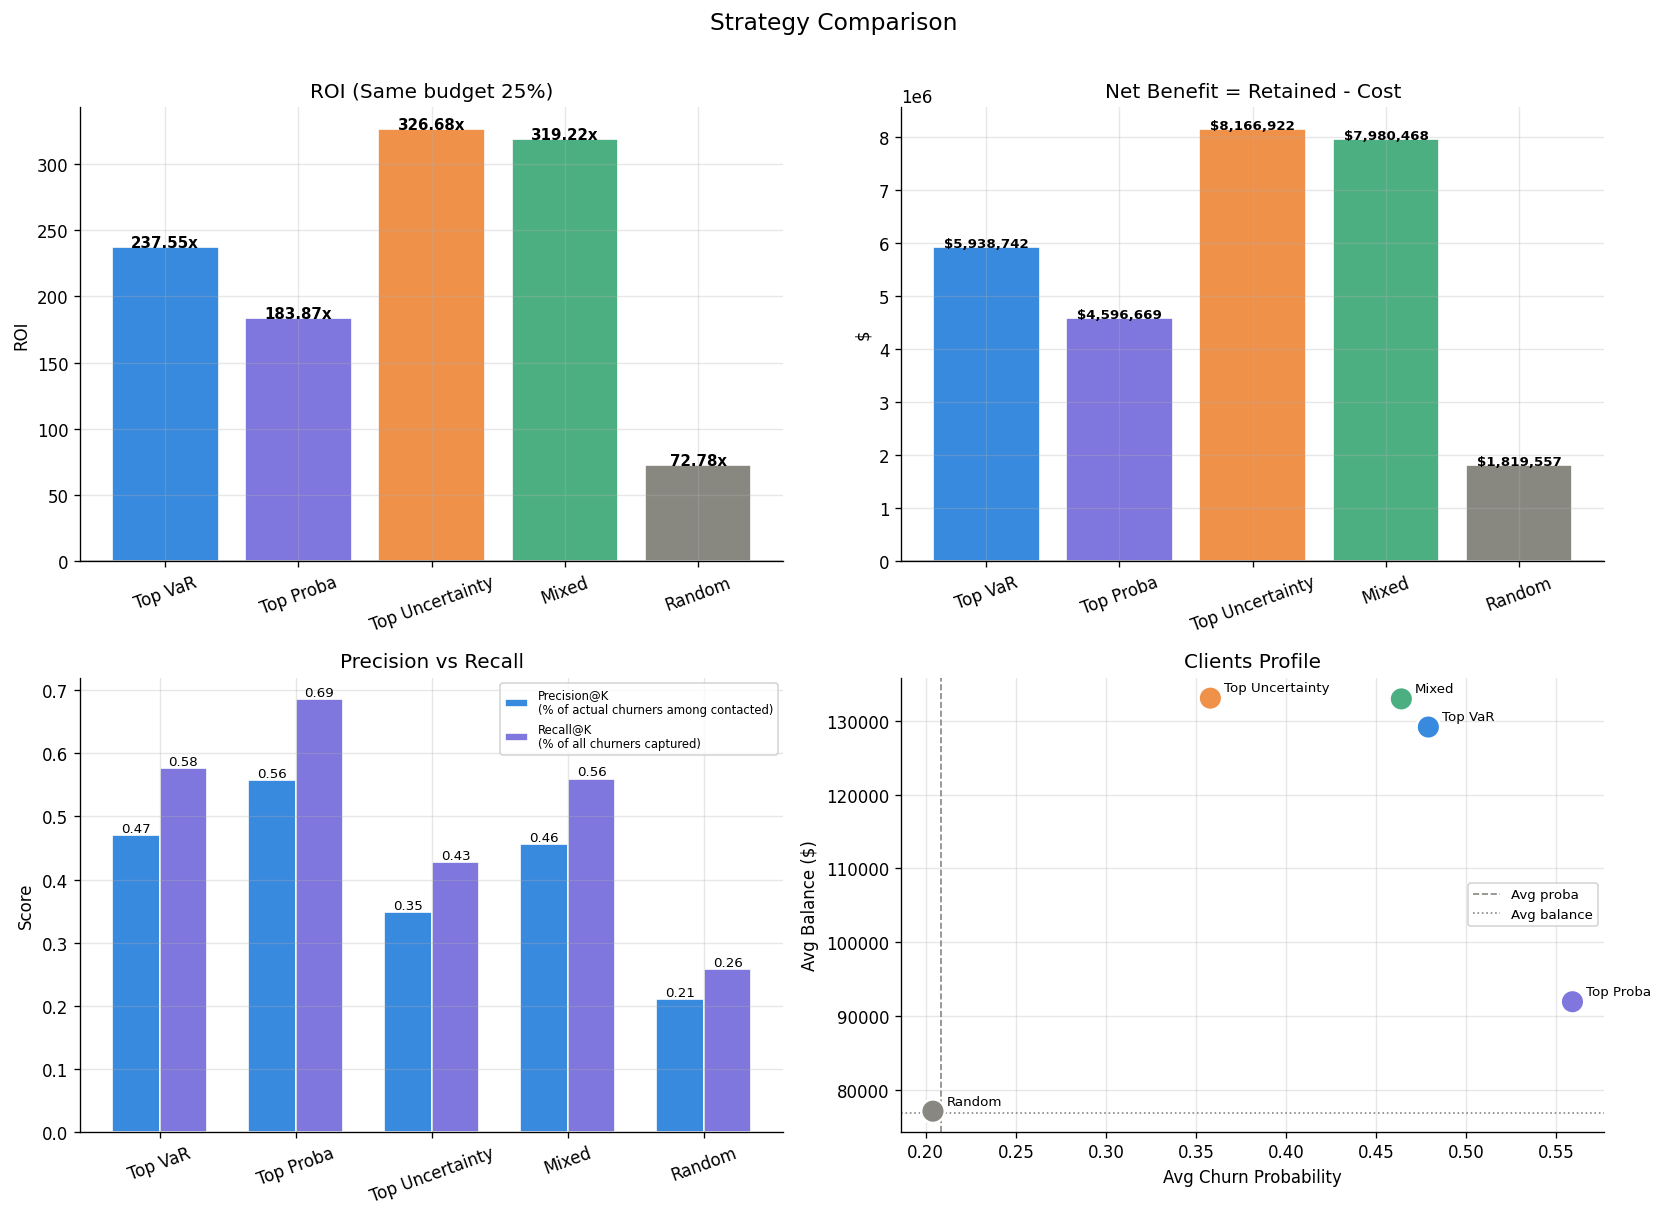

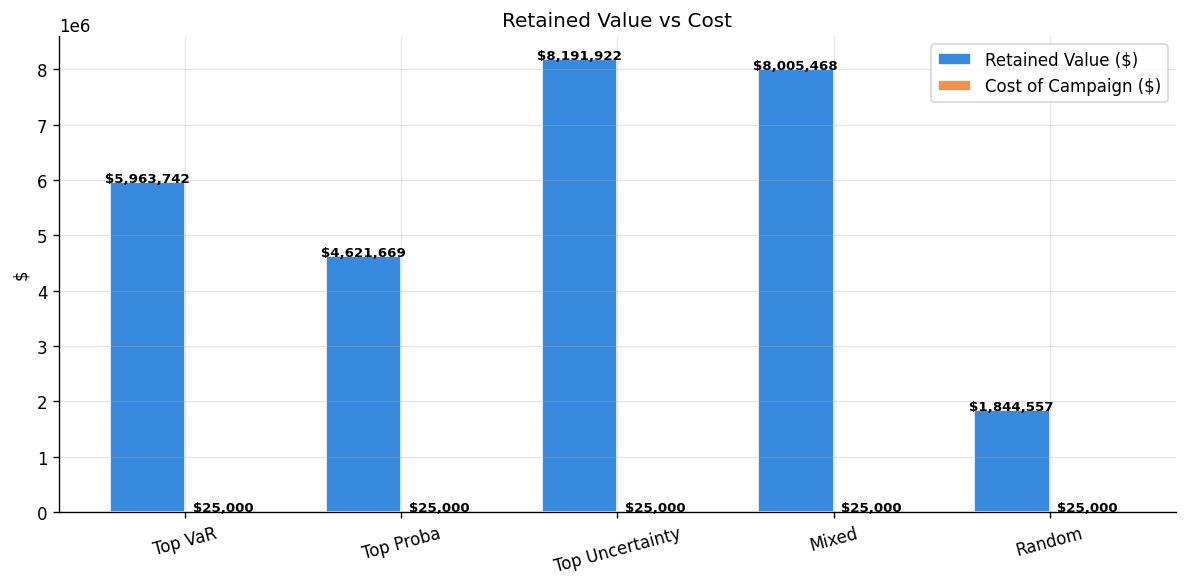

/tmp/ipykernel_850/1819384373.py:343: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  heatmap_data = results.groupby(['decile', 'country'], observed=True).apply(


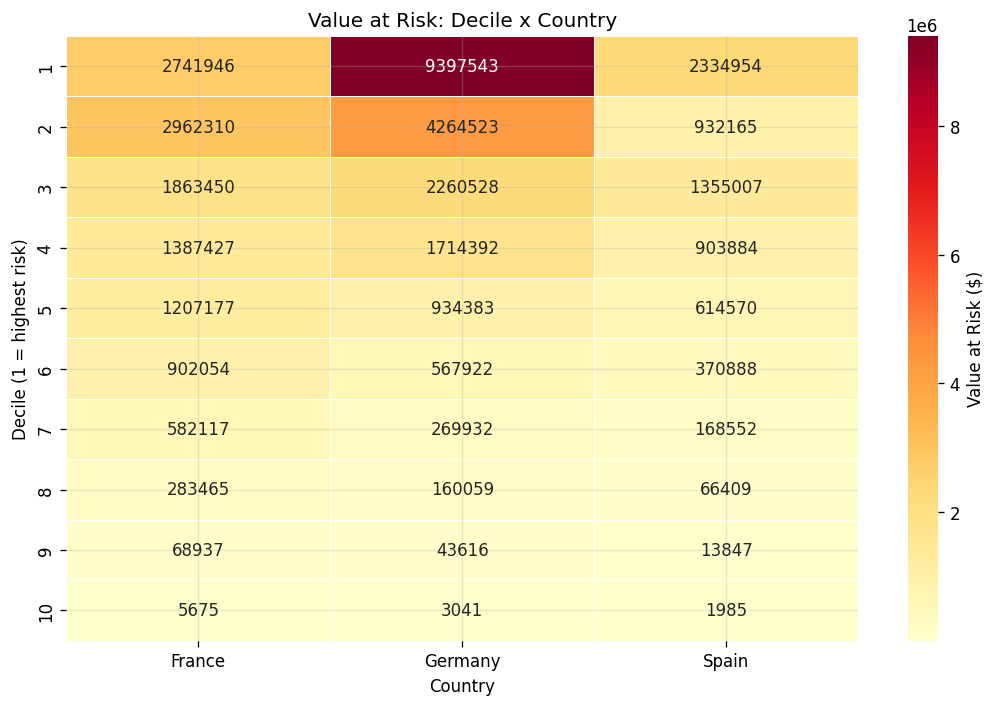

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# ============================================================
# CAMPAIGN PARAMETERS
# ============================================================
COST_PER_CONTACT = 50
BUDGET_FRACTION  = 0.25   # 25% budget for all strategies

# Churn reduction by strategy:
# Top by VaR — wealthy and high-risk, harder to retain
# Top by proba — most likely to churn, also harder to retain
# Top by uncertainty — still undecided, easier to retain
# Mixed — average of the above
CHURN_REDUCTION_MAP = {
    'Top VaR'         : 0.20,
    'Top Proba'       : 0.18,
    'Top Uncertainty' : 0.35,
    'Mixed'           : 0.27,
    'Random'          : 0.20,
}

# ============================================================
# STEP 1. Load data and feature engineering
# ============================================================
df = pd.read_csv('Bank Customer Churn Prediction.csv')

df['age_activity_score']        = df['age'] * (1 - df['active_member'])
df['is_multi_product_customer'] = (df['products_number'] > 1).astype(int)
df['high_risk_products']        = (df['products_number'] >= 3).astype(int)
df['zero_balance']              = (df['balance'] == 0).astype(int)

MULTI_CAT_FEATURES = ['country']
BIN_CAT_FEATURES   = [
    'gender', 'active_member', 'credit_card',
    'is_multi_product_customer', 'high_risk_products', 'zero_balance'
]
NUMERICAL_FEATURES = [
    'age', 'tenure', 'balance', 'products_number',
    'credit_score', 'estimated_salary', 'age_activity_score'
]

X = df[NUMERICAL_FEATURES + BIN_CAT_FEATURES + MULTI_CAT_FEATURES]
y = df['churn']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(),            NUMERICAL_FEATURES),
    ('bin', OrdinalEncoder(),            BIN_CAT_FEATURES),
    ('cat', OneHotEncoder(drop='first'), MULTI_CAT_FEATURES),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready  = preprocessor.transform(X_test)

# ============================================================
# STEP 2. Train the model
# ============================================================
model = RandomForestClassifier(n_estimators=200, max_depth=20,
                               min_samples_leaf=1, random_state=42, n_jobs=-1)
model.fit(X_train_ready, y_train)

churn_proba = model.predict_proba(X_test_ready)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, churn_proba):.4f}")

# ============================================================
# STEP 3. Build results dataframe + scoring scores per strategy
# ============================================================
results = X_test.copy()
results['churn']       = y_test.values
results['churn_proba'] = churn_proba

# Score 1: Value at Risk — balance x probability
results['score_var'] = results['balance'] * results['churn_proba']

# Score 2: Raw churn probability
results['score_proba'] = results['churn_proba']

# Score 3: Uncertainty — customers who are still undecided (proba close to 0.5)
# proba x (1 - proba) is maximal at 0.5 and drops toward 0 and 1
# multiplied by balance to focus on valuable, undecided customers
results['score_uncertainty'] = results['balance'] * results['churn_proba'] * (1 - results['churn_proba'])

# ============================================================
# STEP 4. Deciles (for the lift chart)
# ============================================================
results['decile'] = pd.qcut(
    results['churn_proba'].rank(method='first', ascending=False),
    10, labels=range(1, 11)
)

overall_churn_rate = results['churn'].mean()
total_churners     = results['churn'].sum()
n_total            = len(results)

decile_summary = results.groupby('decile', observed=True).agg(
    n_customers  = ('churn',       'count'),
    actual_churn = ('churn',       'sum'),
    churn_rate   = ('churn',       'mean'),
    avg_balance  = ('balance',     'mean'),
    avg_proba    = ('churn_proba', 'mean'),
).reset_index()

decile_summary['value_at_risk']      = decile_summary['avg_balance'] * decile_summary['churn_rate'] * decile_summary['n_customers']
decile_summary['lift']               = decile_summary['churn_rate'] / overall_churn_rate
decile_summary['cumulative_churners']= decile_summary['actual_churn'].cumsum()
decile_summary['cumulative_gain_pct']= decile_summary['cumulative_churners'] / total_churners * 100
decile_summary['cumulative_pop_pct'] = decile_summary['n_customers'].cumsum() / n_total * 100

# ============================================================
# STEP 5. Simulate all strategies
# ============================================================
def simulate(chosen, strategy_name):
    cr   = CHURN_REDUCTION_MAP[strategy_name]
    n    = len(chosen)
    cost = n * COST_PER_CONTACT

    retained_value = (chosen['balance'] * chosen['churn_proba'] * cr).sum()
    net_benefit    = retained_value - cost
    roi            = net_benefit / cost if cost > 0 else 0
    precision_k    = chosen['churn'].sum() / n
    recall_k       = chosen['churn'].sum() / total_churners
    avg_balance    = chosen['balance'].mean()
    avg_proba      = chosen['churn_proba'].mean()

    return {
        'Strategy'            : strategy_name,
        'Churn Reduction'     : f"{cr*100:.0f}%",
        'Contacts (#)'        : n,
        'Cost ($)'            : round(cost, 0),
        'Avg Balance ($)'     : round(avg_balance, 0),
        'Avg Churn Proba'     : round(avg_proba, 3),
        'Retained Value ($)'  : round(retained_value, 0),
        'Net Benefit ($)'     : round(net_benefit, 0),
        'ROI'                 : round(roi, 3),
        'Precision@K'         : round(precision_k, 3),
        'Recall@K'            : round(recall_k, 3),
    }

n_contact = int(n_total * BUDGET_FRACTION)

# Each strategy selects customers based on its own score
chosen_var         = results.nlargest(n_contact, 'score_var')
chosen_proba       = results.nlargest(n_contact, 'score_proba')
chosen_uncertainty = results.nlargest(n_contact, 'score_uncertainty')
chosen_random      = results.sample(n=n_contact, random_state=42)

# Mixed: 60% of the budget on VaR + 40% on Uncertainty (no overlap)
n_var_mixed  = int(n_contact * 0.6)
n_unc_mixed  = n_contact - n_var_mixed
top_var_idx  = results.nlargest(n_var_mixed, 'score_var').index
remaining    = results.drop(top_var_idx)
top_unc_idx  = remaining.nlargest(n_unc_mixed, 'score_uncertainty').index
chosen_mixed = results.loc[list(top_var_idx) + list(top_unc_idx)]

rows = [
    simulate(chosen_var,         'Top VaR'),
    simulate(chosen_proba,       'Top Proba'),
    simulate(chosen_uncertainty, 'Top Uncertainty'),
    simulate(chosen_mixed,       'Mixed'),
    simulate(chosen_random,      'Random'),
]

strategy_df = pd.DataFrame(rows).set_index('Strategy')
print("\n--- Strategy comparison (same 25% budget) ---")
print(strategy_df.to_string())

# ============================================================
# STEP 6. Visualizations
# ============================================================
C_RED    = '#E24B4A'
C_BLUE   = '#378ADD'
C_PURPLE = '#7F77DD'
C_ORANGE = '#F0914A'
C_GREEN  = '#4CAF82'
C_GRAY   = '#888780'

COLORS = [C_BLUE, C_PURPLE, C_ORANGE, C_GREEN, C_GRAY]

plt.rcParams.update({
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'figure.dpi'       : 120,
})

strat_labels = strategy_df.index.tolist()

# ─────────────────────────────────────────────
# Chart 1: Lift Chart
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = [C_RED if i < 3 else C_BLUE for i in range(len(decile_summary))]
bars = ax.bar(decile_summary['decile'].astype(str),
              decile_summary['churn_rate'] * 100,
              color=colors, edgecolor='white')
for bar, lift in zip(bars, decile_summary['lift']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'x{lift:.1f}', ha='center', va='bottom', fontsize=8, color='dimgray')
ax.axhline(overall_churn_rate * 100, color='black', linestyle='--',
           linewidth=1.2, label=f'Avg churn rate ({overall_churn_rate*100:.1f}%)')
ax.set_xlabel('Decile (1 = highest risk)')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Lift Chart: churn rate by decile')
ax.legend()
plt.tight_layout()
plt.savefig('lift_chart.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# Chart 2: Cumulative Gains
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot([0] + list(decile_summary['cumulative_pop_pct']),
        [0] + list(decile_summary['cumulative_gain_pct']),
        marker='o', color=C_BLUE, linewidth=2.5, markersize=6, label='Model')
ax.plot([0, 100], [0, 100], '--', color=C_GRAY, linewidth=1.2, label='Random baseline')
ax.fill_between([0] + list(decile_summary['cumulative_pop_pct']),
                [0] + list(decile_summary['cumulative_gain_pct']),
                [0] + list(decile_summary['cumulative_pop_pct']),
                alpha=0.1, color=C_BLUE)
gain_at_25 = decile_summary.iloc[1]['cumulative_gain_pct']
ax.axvline(25, color=C_PURPLE, linestyle=':', linewidth=1.5)
ax.annotate(f"Top 25% -> {gain_at_25:.0f}% of churners",
            xy=(25, gain_at_25), xytext=(35, gain_at_25 - 12),
            arrowprops=dict(arrowstyle='->', color=C_PURPLE),
            fontsize=9, color=C_PURPLE)
ax.set_xlabel('% of customers contacted')
ax.set_ylabel('% of churners captured')
ax.set_title('Cumulative Gains Chart')
ax.legend()
plt.tight_layout()
plt.savefig('cumulative_gains.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# Chart 3: Main strategy comparison (2x2)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 3a: ROI
ax = axes[0, 0]
roi_vals   = strategy_df['ROI'].astype(float)
colors_roi = [C_RED if v < 0 else c for v, c in zip(roi_vals, COLORS)]
bars = ax.bar(strat_labels, roi_vals, color=colors_roi, edgecolor='white')
for bar, val in zip(bars, roi_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.2f}x', ha='center', fontsize=9, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('ROI (Same budget 25%)')
ax.set_ylabel('ROI')
ax.tick_params(axis='x', rotation=20)

# 3b: Net Benefit
ax = axes[0, 1]
net_vals   = strategy_df['Net Benefit ($)'].astype(float)
colors_net = [C_RED if v < 0 else c for v, c in zip(net_vals, COLORS)]
bars = ax.bar(strat_labels, net_vals, color=colors_net, edgecolor='white')
for bar, val in zip(bars, net_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'${val:,.0f}', ha='center', fontsize=8, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Net Benefit = Retained - Cost')
ax.set_ylabel('$')
ax.tick_params(axis='x', rotation=20)

# 3c: Precision vs Recall
ax = axes[1, 0]
x     = np.arange(len(strat_labels))
width = 0.35
prec  = strategy_df['Precision@K'].astype(float)
rec   = strategy_df['Recall@K'].astype(float)
ax.bar(x - width/2, prec, width, label='Precision@K\n(% of actual churners among contacted)', color=C_BLUE,   edgecolor='white')
ax.bar(x + width/2, rec,  width, label='Recall@K\n(% of all churners captured)',              color=C_PURPLE, edgecolor='white')
for i, (p, r) in enumerate(zip(prec, rec)):
    ax.text(i - width/2, p + 0.005, f'{p:.2f}', ha='center', fontsize=8)
    ax.text(i + width/2, r + 0.005, f'{r:.2f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(strat_labels, rotation=20)
ax.set_title('Precision vs Recall')
ax.set_ylabel('Score')
ax.legend(fontsize=7)

# 3d: Avg Balance vs Avg Churn Proba — profile of contacted customers
ax = axes[1, 1]
avg_bal  = strategy_df['Avg Balance ($)'].astype(float)
avg_prob = strategy_df['Avg Churn Proba'].astype(float)
scatter  = ax.scatter(avg_prob, avg_bal, c=COLORS, s=200, zorder=5, edgecolors='white', linewidth=1.5)
for i, label in enumerate(strat_labels):
    ax.annotate(label, (avg_prob.iloc[i], avg_bal.iloc[i]),
                textcoords='offset points', xytext=(8, 4), fontsize=8)
ax.set_xlabel('Avg Churn Probability')
ax.set_ylabel('Avg Balance ($)')
ax.set_title('Clients Profile')
ax.axvline(results['churn_proba'].mean(), color=C_GRAY, linestyle='--', linewidth=1, label='Avg proba')
ax.axhline(results['balance'].mean(),     color=C_GRAY, linestyle=':',  linewidth=1, label='Avg balance')
ax.legend(fontsize=8)

plt.suptitle('Strategy Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('strategy_comparison_full.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# Chart 4: Retained Value vs Cost (business-friendly view)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(strat_labels))
width = 0.35
ret   = strategy_df['Retained Value ($)'].astype(float)
cost  = strategy_df['Cost ($)'].astype(float)
ax.bar(x - width/2, ret,  width, label='Retained Value ($)', color=C_BLUE,   edgecolor='white')
ax.bar(x + width/2, cost, width, label='Cost of Campaign ($)', color=C_ORANGE, edgecolor='white')
for i, (r, c) in enumerate(zip(ret, cost)):
    ax.text(i - width/2, r + 100, f'${r:,.0f}', ha='center', fontsize=8, fontweight='bold')
    ax.text(i + width/2, c + 100, f'${c:,.0f}', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strat_labels, rotation=15)
ax.set_ylabel('$')
ax.set_title('Retained Value vs Cost')
ax.legend()
plt.tight_layout()
plt.savefig('retained_vs_cost.png', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# Chart 5: VaR heatmap by decile and country
# ─────────────────────────────────────────────
heatmap_data = results.groupby(['decile', 'country'], observed=True).apply(
    lambda d: (d['balance'] * d['churn_proba']).sum()
).unstack()

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Value at Risk ($)'})
ax.set_title('Value at Risk: Decile x Country')
ax.set_xlabel('Country')
ax.set_ylabel('Decile (1 = highest risk)')
plt.tight_layout()
plt.savefig('heatmap_var.png', bbox_inches='tight')
plt.show()